In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import joblib

In [2]:
df_clean = pd.read_csv("../data/processed/cleaned_train_data.csv")

df_clean.head()

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,patientid,City_Code_Patient,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911.0,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954.0,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745.0,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272.0,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558.0,41-50


## Feature Engineering

In [ ]:
df_ml = df_clean.copy()

In [4]:
df_ml.drop(
    columns=["case_id", "patientid"],
    inplace=True
)

In [5]:
df_ml.head()

,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,City_Code_Patient,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay
0,8,c,3,Z,3,radiotherapy,R,F,2.0,7.0,Emergency,Extreme,2,51-60,4911.0,0-10
1,2,c,5,Z,2,radiotherapy,S,F,2.0,7.0,Trauma,Extreme,2,51-60,5954.0,41-50
2,10,e,1,X,2,anesthesia,S,E,2.0,7.0,Trauma,Extreme,2,51-60,4745.0,31-40
3,26,b,2,Y,2,radiotherapy,R,D,2.0,7.0,Trauma,Extreme,2,51-60,7272.0,41-50
4,26,b,2,Y,2,radiotherapy,S,D,2.0,7.0,Trauma,Extreme,2,51-60,5558.0,41-50


In [6]:
label_encoders = {}

label_columns = [
    "Age",
    "Severity of Illness"
]

for column in label_columns:
    encoder = LabelEncoder()
    df_ml[column] = encoder.fit_transform(df_ml[column])
    label_encoders[column] = encoder

In [7]:
print(df_ml["Bed Grade"].isnull().sum())

113


In [8]:
df_ml["Bed Grade"] = df_ml["Bed Grade"].fillna(
    df_ml["Bed Grade"].mode()[0]
)

In [9]:
df_ml["Bed Grade"] = df_ml["Bed Grade"].astype(int)

In [10]:
df_ml = pd.get_dummies(
    df_ml,
    columns=[
        "Hospital_type_code",
        "Hospital_region_code",
        "Department",
        "Ward_Type",
        "Ward_Facility_Code",
        "Type of Admission"
    ]
)

In [11]:
df_ml.head()

,Hospital_code,City_Code_Hospital,Available Extra Rooms in Hospital,Bed Grade,City_Code_Patient,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay,...,Ward_Type_U,Ward_Facility_Code_A,Ward_Facility_Code_B,Ward_Facility_Code_C,Ward_Facility_Code_D,Ward_Facility_Code_E,Ward_Facility_Code_F,Type of Admission_Emergency,Type of Admission_Trauma,Type of Admission_Urgent
0,8,3,3,2,7.0,0,2,5,4911.0,0-10,...,False,False,False,False,False,False,True,True,False,False
1,2,5,2,2,7.0,0,2,5,5954.0,41-50,...,False,False,False,False,False,False,True,False,True,False
2,10,1,2,2,7.0,0,2,5,4745.0,31-40,...,False,False,False,False,False,True,False,False,True,False
3,26,2,2,2,7.0,0,2,5,7272.0,41-50,...,False,False,False,False,True,False,False,False,True,False
4,26,2,2,2,7.0,0,2,5,5558.0,41-50,...,False,False,False,False,True,False,False,False,True,False


In [12]:
df_ml.shape

(318438, 40)

## Features and Target

In [33]:
X = df_ml.drop("Stay", axis=1)

y = df_ml["Stay"]

feature_columns = X.columns.tolist()

In [14]:
print(X.shape)
print(y.shape)

(318438, 39)
(318438,)


## Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(254750, 39)
(63688, 39)
(254750,)
(63688,)


## Model Training

In [17]:
model = DecisionTreeClassifier(
    random_state=42
)

In [18]:
model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [19]:
model

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Prediction

In [20]:
y_pred = model.predict(X_test)

In [21]:
y_pred[:10]

array(['11-20', '51-60', '21-30', '0-10', '21-30', '11-20', '31-40',
       '11-20', '21-30', '31-40'], dtype=object)

In [22]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
245328,51-60,11-20
239123,51-60,51-60
280646,21-30,21-30
89025,21-30,0-10
517,31-40,21-30
275285,31-40,11-20
221020,More than 100 Days,31-40
297989,11-20,11-20
128961,0-10,21-30
208348,11-20,31-40


## Model Evaluation

In [23]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy : {accuracy:.2f}")

Accuracy : 0.30


In [24]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[ 944, 1471, 1285,  534,  161,  162,   40,   56,   12,    7,   17],
       [1528, 5304, 4620, 2231,  566,  843,  110,  206,   57,   43,   53],
       [1395, 4731, 6728, 2696,  845,  695,  155,  185,   60,   35,   78],
       [ 523, 2068, 2568, 2773,  481, 1658,  124,  440,  148,   85,  113],
       [ 181,  536,  680,  449,  168,  186,   28,   59,   29,   18,   23],
       [ 184,  764,  704, 1734,  190, 2168,   65,  619,  266,  182,  252],
       [  31,   89,  120,  117,   34,   82,   15,   31,   13,    7,   15],
       [  45,  174,  173,  433,   55,  569,   17,  305,   58,   75,  127],
       [  15,   49,   57,  126,   16,  279,    9,   55,  198,   14,  123],
       [   8,   48,   38,   97,   16,  156,    5,   66,   12,   57,   49],
       [  21,   59,   73,  120,   25,  217,   11,  137,  109,   46,  473]])

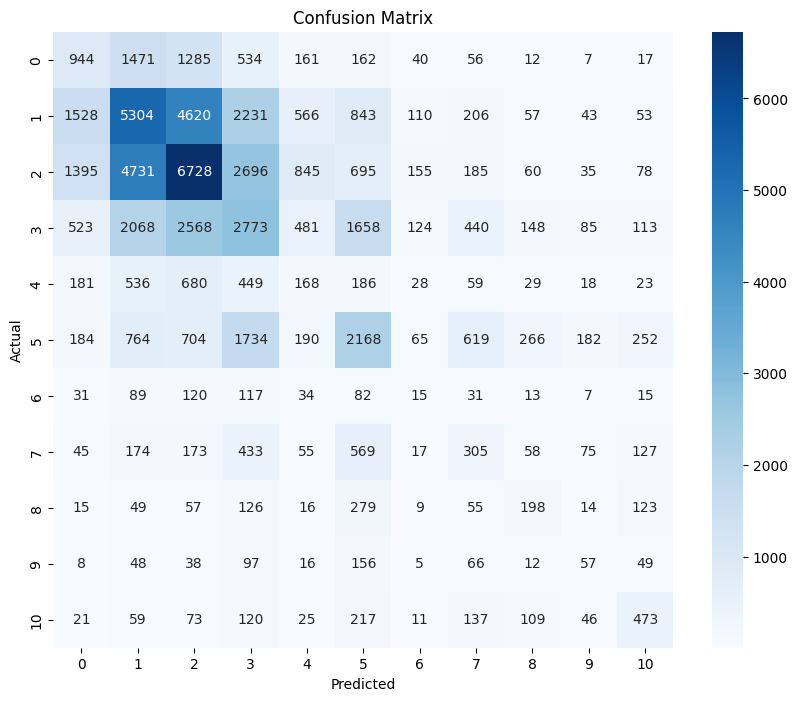

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [26]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Precision : {precision:.4f}")

Precision : 0.3033


In [27]:
recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Recall : {recall:.4f}")

Recall : 0.3004


In [28]:
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.3018


In [29]:

print("MODEL PERFORMANCE")


print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

MODEL PERFORMANCE
Accuracy  : 0.3004
Precision : 0.3033
Recall    : 0.3004
F1 Score  : 0.3018


In [30]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                    precision    recall  f1-score   support

              0-10       0.19      0.20      0.20      4689
             11-20       0.35      0.34      0.34     15561
             21-30       0.39      0.38      0.39     17603
             31-40       0.25      0.25      0.25     10981
             41-50       0.07      0.07      0.07      2357
             51-60       0.31      0.30      0.31      7128
             61-70       0.03      0.03      0.03       554
             71-80       0.14      0.15      0.15      2031
             81-90       0.21      0.21      0.21       941
            91-100       0.10      0.10      0.10       552
More than 100 Days       0.36      0.37      0.36      1291

          accuracy                           0.30     63688
         macro avg       0.22      0.22      0.22     63688
      weighted avg       0.30      0.30      0.30     63688



In [31]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0-10,0.193641,0.201322,0.197407,4689.000000
11-20,0.346825,0.340852,0.343813,15561.000000
21-30,0.394697,0.382208,0.388352,17603.000000
31-40,0.245181,0.252527,0.248800,10981.000000
41-50,0.065702,0.071277,0.068376,2357.000000
51-60,0.309052,0.304153,0.306583,7128.000000
61-70,0.025907,0.027076,0.026478,554.000000
71-80,0.141269,0.150172,0.145585,2031.000000
81-90,0.205821,0.210414,0.208092,941.000000
91-100,0.100176,0.103261,0.101695,552.000000


## Save Model

In [34]:
joblib.dump(
    model,
    "../models/decision_tree_model.pkl"
)

with open("../models/label_encoders.pkl", "wb") as file:
    pickle.dump(label_encoders, file)

with open("../models/feature_columns.pkl", "wb") as file:
    pickle.dump(feature_columns, file)

In [35]:
print(type(model))
print(type(label_encoders))
print(type(feature_columns))

<class 'sklearn.tree._classes.DecisionTreeClassifier'>
<class 'dict'>
<class 'list'>


In [ ]:
loaded_model = joblib.load(
    "../models/decision_tree_model.pkl"
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:

print("MODEL TRAINING SUMMARY")


print(f"Algorithm        : Decision Tree Classifier")
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")
print(f"Classes          : {y.nunique()}")
print(f"Accuracy         : {accuracy:.4f}")

print("\nModel saved successfully!")

MODEL TRAINING SUMMARY
Algorithm        : Decision Tree Classifier
Training Samples : 254750
Testing Samples  : 63688
Features         : 39
Classes          : 11
Accuracy         : 0.3004

Model saved successfully!
